In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as numnpy


In [3]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\benja\Documents\Tarea1\.vscode\2023-03-08_Precios_Casas_RM.csv",
    sep=","
)

df.head()

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4.0,384.0,732.0,3.0,11700213,NaN
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1.0,112.0,145.0,1.0,10894299,Legales y Propiedades SpA
2,128124000,3600,159557,EstaciónCentral,AvenidaLasParcelas,3,1.0,59.0,243.0,2.0,10257635,Propiedadesrs
3,75000000,2107,93400,Colina,PasajeGonzaloRojas,3,1.0,103.0,73.0,1.0,9232092,Patricio Gajardo propiedades
4,53000000,1489,66002,Colina,HernánDíazArrieta2820,2,1.0,57.0,67.0,1.0,7085397,Patricio Gajardo propiedades


In [4]:
print(df.columns)

Index(['Price_CLP', 'Price_UF', 'Price_USD', 'Comuna', 'Ubicacion', 'Dorms',
       'Baths', 'Built Area', 'Total Area', 'Parking', 'id', 'Realtor'],
      dtype='str')


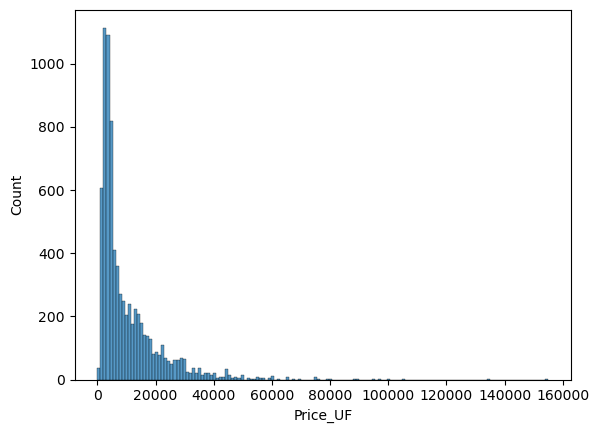

In [5]:
sns.histplot(data=df, x="Price_UF")
plt.show()



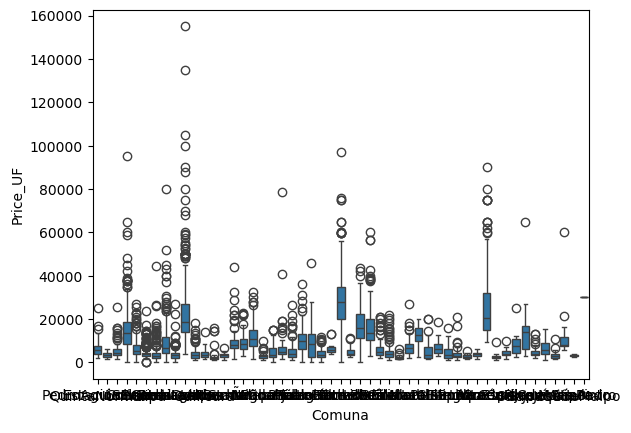

In [ ]:
sns.boxplot(data=df, x="Comuna", y="Price_UF")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet  # Modelos vistos en clases
from sklearn.model_selection import train_test_split, cross_val_score  # Cross validation
from sklearn.preprocessing import StandardScaler  # Estandarizar datos
from sklearn.pipeline import Pipeline  # Generar pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # Evaluar modelo
from sklearn.preprocessing import PolynomialFeatures  # Agregar polinomial

In [ ]:
x = df.drop(columns=["Price_UF"])  # Features
y = df["Price_UF"]  # Variable de respuesta

x, y

(       Price_CLP  Price_USD             Comuna  \
 0      409285000     509695       QuintaNormal   
 1      105000000     130760  PedroAguirreCerda   
 2      128124000     159557    EstaciónCentral   
 3       75000000      93400             Colina   
 4       53000000      66002             Colina   
 ...          ...        ...                ...   
 7774  2491300000    3102491          LasCondes   
 7775   242012000     301385          Peñalolén   
 7776  3736950000    4653736          LasCondes   
 7777   569440000     709141          LaPintana   
 7778   355828820     443124          Talagante   
 
                              Ubicacion  Dorms  Baths  Built Area  Total Area  \
 0                      Hoevel4548y4558      7    4.0       384.0       732.0   
 1                             Rucalhue      2    1.0       112.0       145.0   
 2                   AvenidaLasParcelas      3    1.0        59.0       243.0   
 3                   PasajeGonzaloRojas      3    1.0       10

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((6223, 11), (1556, 11), (6223,), (1556,))

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2)),
    ("model", LinearRegression())
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [ ]:
df.head()

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4.0,384.0,732.0,3.0,11700213,NaN
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1.0,112.0,145.0,1.0,10894299,Legales y Propiedades SpA
2,128124000,3600,159557,EstaciónCentral,AvenidaLasParcelas,3,1.0,59.0,243.0,2.0,10257635,Propiedadesrs
3,75000000,2107,93400,Colina,PasajeGonzaloRojas,3,1.0,103.0,73.0,1.0,9232092,Patricio Gajardo propiedades
4,53000000,1489,66002,Colina,HernánDíazArrieta2820,2,1.0,57.0,67.0,1.0,7085397,Patricio Gajardo propiedades


In [ ]:
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")
print(scores)
print(scores.mean(), scores.std())

[0.99995467 0.99981343 0.99982333 0.97645581 0.99957139]
0.9951237252084317 0.00933477662019554


In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

El modelo inicial obtuvo un R² promedio de 0,696 en validación cruzada, por lo que no cumplía, buscaremos que r2 sea mayor 0.8


In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer

# Separar columnas numéricas y categóricas
columnas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = X_train.select_dtypes(include=["object"]).columns

# Transformador para números
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Transformador para texto/categorías
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocesamiento completo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, columnas_numericas),
        ("cat", categorical_transformer, columnas_categoricas)
    ]
)

# Modelo potente para subir R2
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None
    ))
])

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(scores)
print("R2 promedio CV:", scores.mean())
print("Desviación:", scores.std())

C:\Users\benja\AppData\Local\Temp\ipykernel_6512\1366573538.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X_train.select_dtypes(include=["object"]).columns


[0.99998912 0.9999955  0.99996695 0.9671215  0.99995062]
R2 promedio CV: 0.9934047355294421
Desviación: 0.013141629537258934


Se logró mejorar el modelo usando un pipeline con tratamiento de variables categóricas mediante OneHotEncoder.
El resultado obtuvo un R² promedio en CV de 0.9934, superando ampliamente el objetivo de R² > 0.8.
La desviación estándar fue baja (0.0131), lo que indica estabilidad entre las particiones.
Aunque un fold tuvo menor rendimiento (0.967), el desempeño general sigue siendo muy alto.